Welcome to Week 3!

We will be focussing in Particle Physics Analysis and detecting matter/antimatter assymetries in the production of certain types of particles.


![LHCb detector](https://www1b.physik.rwth-aachen.de/~schael/LHCb_files/LHCB%20PREVIEW-white-bg.jpg)

The data we are using comes from LHCb - one of the experiments at LHC. It is a highly specialised detector aimed at detecting decays involving the B-quark. Unlike the other major experiments, LHCb detects particles very close to the source and looks almost exclusively in the forward direction - this gives the detector many advantages compared to other experiments at LHC.

In order to get started, we need to access the [ROOT framework](https://root.cern.ch/) through a python package for that - [upROOT](https://pypi.org/project/uproot/) and download some datafiles into your environment!.

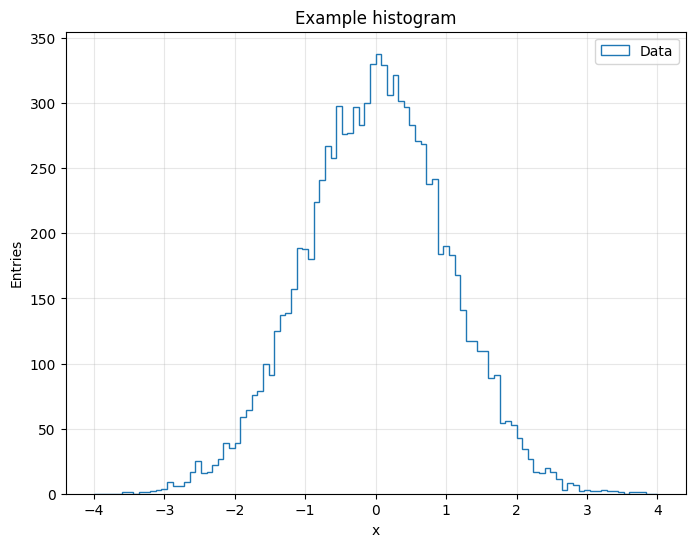

In [185]:
# We use NumPy for numerical work and random numbers
# Matplotlib is used for plotting as before
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


# SciPy provides fitting tools, similar to ROOT's Fit("gaus")
from scipy.stats import norm


# ------------------------------------------------------------
# 1. Generate Gaussian-distributed random numbers
#    (equivalent to h.FillRandom("gaus"))
# ------------------------------------------------------------

# Mean (mu) and standard deviation (sigma) of the Gaussian
mu = 0.0
sigma = 1.0

# Number of entries to generate (like number of fills)
n_entries = 10000

# Generate random data
data = np.random.normal(loc=mu, scale=sigma, size=n_entries)


# ------------------------------------------------------------
# 2. Create a histogram (We will do this alot today...))
# ------------------------------------------------------------

# Histogram settings - choose your own
n_bins = 100
x_min, x_max = -4, 4

# Create the figure and axes
fig, ax = plt.subplots(figsize=(8, 6))


counts, bin_edges, _ = ax.hist(
    data,
    bins=n_bins,
    range=(x_min, x_max),
    histtype="step",
    label="Data"
)


# ------------------------------------------------------------
# 3. Labels, title, and final touches
# ------------------------------------------------------------

ax.set_title("Example histogram")
ax.set_xlabel("x")
ax.set_ylabel("Entries")

ax.legend()
ax.grid(alpha=0.3)

# Display the plot
plt.show()



All being well - this should give no errors and we should have some kind of Gaussian distribution above.

We now want to do two things, install uproot - and get our data file from the CERN open data storage location.

This will probably be ratelimited very quickly, so you can find it on Canvas here: https://canvas.maastrichtuniversity.nl/courses/26553/files/6101104?module_item_id=1009080

Then upload it directly.

In [186]:
!pip install uproot


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [187]:
!mkdir LHCb_Data && cd LHCb_Data && wget http://opendata.cern.ch/record/4900/files/B2HHH_MagnetDown.root

mkdir: LHCb_Data: File exists


In [188]:
import uproot

# Open the ROOT file
file = uproot.open("B2HHH_MagnetDown.root")

# List coSSntents (shows us what is inside)
file.keys()

# Access the tree
tree = file["DecayTree"]

# Read one branch as a NumPy array
px = tree["H1_PX"].array(library="np")

print(len(tree))
print(px)
len(px)

26
[  375.2842054  -4985.13078543 -1265.45654435 ...  2606.91083928
  -294.71098895   499.04234923]


5135823

169827.25628488915 -92785.61289394063


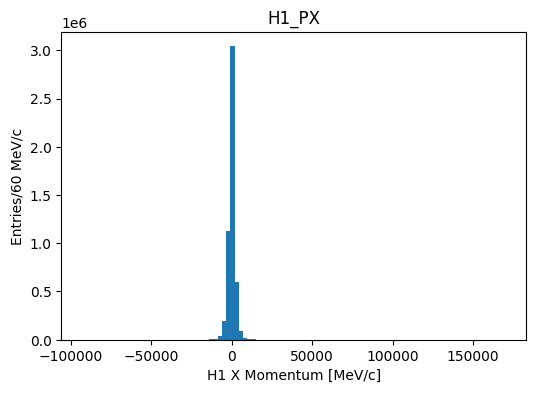

In [189]:
# now our data is an array - we can plot it :)

plt.figure(figsize=(6, 4))

px_max = px.max()
px_min = px.min()


print(px.max(), px.min())

#play with the variables below ...
plt.hist(
    px,
    bins=100,
    range=(px_min, px_max),
    histtype="bar"
)

#Add some labels...

plt.xlabel("H1 X Momentum [MeV/c]")
plt.ylabel("Entries/60 MeV/c")
plt.title("H1_PX")

plt.show()

After looking through all possible x momenta, i decided to focus on a clearly visible range with more data.

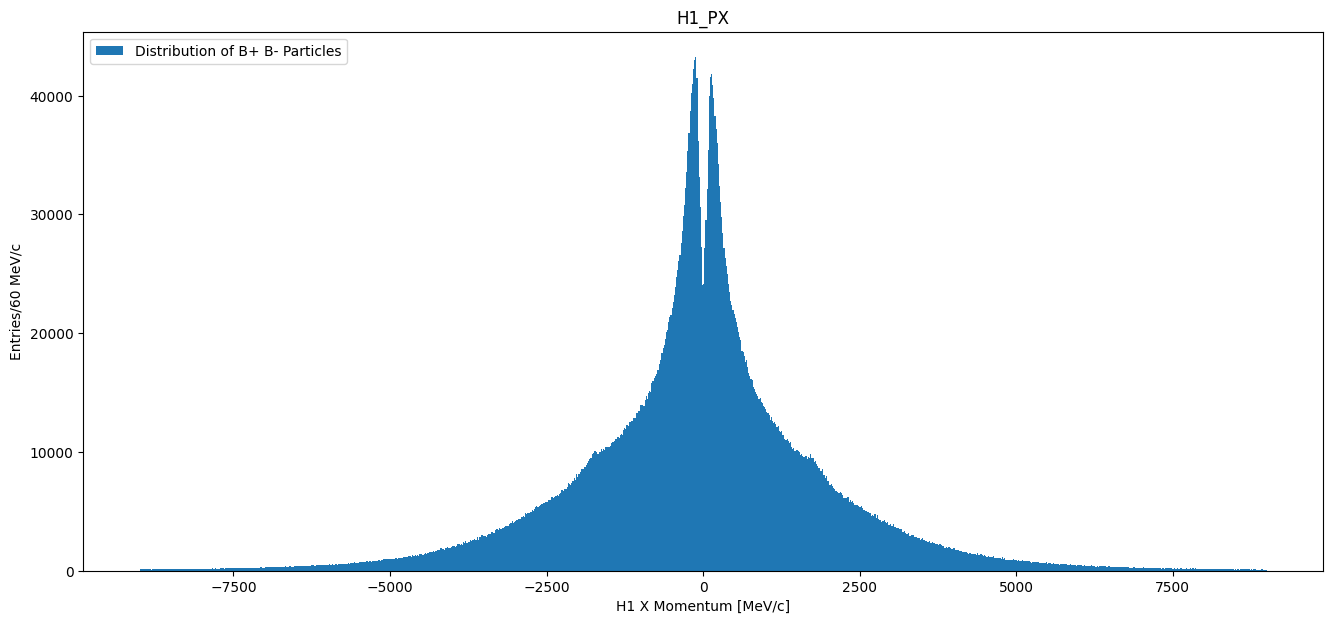

In [190]:
#notice that most data shows up in ~10 bins close to the -9000/9000 range

fig = plt.figure(figsize=[16,7])
plt.hist(px, bins=1000, range=(-9000, 9000), histtype="bar", label="Distribution of B+ B- Particles")
plt.xlabel("H1 X Momentum [MeV/c]")
plt.ylabel("Entries/60 MeV/c")
plt.legend(loc="upper left")
plt.title("H1_PX")

plt.show()
#chosing not to record low x_momentum as trigger, theyre hard to reconstruct


This is the point at which the setup is all working - you can proceed below if you want to look at a basic guide to fitting functions to data using numpy etc.

<>:46: SyntaxWarning: invalid escape sequence '\m'
<>:46: SyntaxWarning: invalid escape sequence '\s'
<>:46: SyntaxWarning: invalid escape sequence '\m'
<>:46: SyntaxWarning: invalid escape sequence '\s'
/var/folders/ct/wgvqwp5j3ds485kw12jx3jd40000gn/T/ipykernel_1366/3214463937.py:46: SyntaxWarning: invalid escape sequence '\m'
  label=f"Gaussian fit\n$\mu={fit_mu:.3f}$, $\sigma={fit_sigma:.3f}$"
/var/folders/ct/wgvqwp5j3ds485kw12jx3jd40000gn/T/ipykernel_1366/3214463937.py:46: SyntaxWarning: invalid escape sequence '\s'
  label=f"Gaussian fit\n$\mu={fit_mu:.3f}$, $\sigma={fit_sigma:.3f}$"


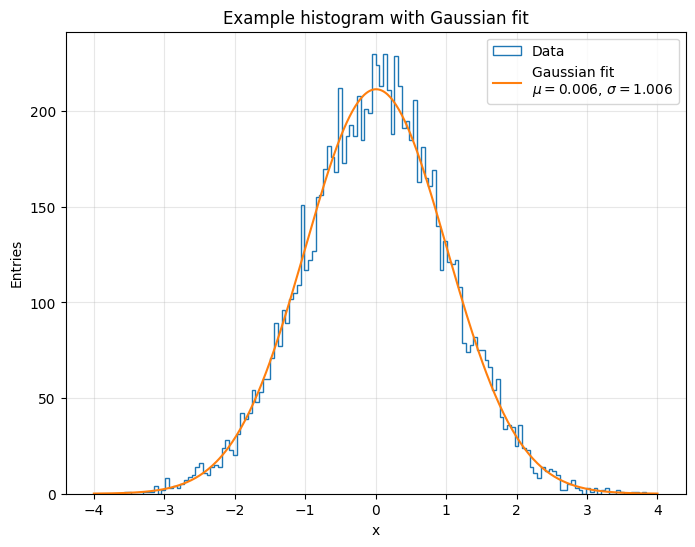

In [191]:
# Histogram settings - choose your own
n_bins = 150
x_min, x_max = -4, 4
n_entries = 10000

# Create the figure and axes

fig, ax = plt.subplots(figsize=(8, 6))


counts, bin_edges, _ = ax.hist(
    data,
    bins=n_bins,
    range=(x_min, x_max),
    histtype="step",
    label="Data"
)

# ------------------------------------------------------------
# Now we perform a Gaussian fit
# ------------------------------------------------------------

# Fit a normal distribution to the data
# norm.fit returns the fitted mean and standard deviation
fit_mu, fit_sigma = norm.fit(data)

# Create x values for drawing the fitted function
x = np.linspace(x_min, x_max, 400)

# Evaluate the fitted Gaussian probability density function
pdf = norm.pdf(x, fit_mu, fit_sigma)

# Convert PDF to expected histogram counts
# (ROOT does this internally; here we scale manually)
bin_width = (x_max - x_min) / n_bins
fit_y = pdf * n_entries * bin_width


# ------------------------------------------------------------
# Draw the fitted Gaussian on top of the histogram
# ------------------------------------------------------------

ax.plot(
    x,
    fit_y,
    label=f"Gaussian fit\n$\mu={fit_mu:.3f}$, $\sigma={fit_sigma:.3f}$"
)


# ------------------------------------------------------------
# abels, title, and final touches
# ------------------------------------------------------------

ax.set_title("Example histogram with Gaussian fit")
ax.set_xlabel("x")
ax.set_ylabel("Entries")

ax.legend()
ax.grid(alpha=0.3)

# Display the plot (equivalent to c.Draw())
plt.show()


## If you are **Here** - and Chris did not make the introduction yet - it's time for a coffee - take a break and wait for instructions about how to proceed.

#Why are we here?

This week is about finding out something about one of the fundemental questions in physics. Why do we have "stuff".

According to many of our models, and according to many measurements in particle physics, matter and anti-matter appear to be produced in equal quantities.

However, when one looks at the Universe in general, we have more matter than anti-matter left - so there need to be some processes where anti-matter and matter are not produced equally. You can find out more about the Matter/Anti-Matter Asymmetry [here](http://press.web.cern.ch/backgrounders/matterantimatter-asymmetry)

One place we look for this asymetry is in [charge-partity (CP) violation](https://www.symmetrymagazine.org/article/october-2005/explain-it-in-60-seconds) in particle physics processes. This essentially says that the processes that happen in the anti-particle version of a decay do not **exactly** match to the processes that happen in the particle version of the decay.



---



At LHCb, we produce both particle of the  B<sup>+</sup> meson and it's antiparticle the B<sup>-</sup> meson.

We cannot detect these mesons directly. They decay into other things before we have a chance to measure them properly. So we collect data on the decay products, often called daughter particles. There are 524 [documented](http://pdg.lbl.gov/2014/listings/rpp2014-list-B-plus-minus.pdf) ways that the B<sup>+/-</sup> decays into various combinations. In order to simplify the process, we choose decay combinations that are convenient or have particular properties.

In this analysis, we will take the process:-

B<sup>+</sup>->K<sup>+</sup> + K<sup>+</sup>  + K<sup>-</sup>

or

B<sup>-</sup>->K<sup>-</sup> + K<sup>-</sup>  + K<sup>+</sup>


To do so, we are given the following data for each event in our system:-

![alt text](https://raw.githubusercontent.com/lhcb/opendata-project/80d64a3796e593fc8f9b257e85f32ae2e54f131f/Images/Variables.png)

Here, H1 is the detected daughter particle (so a Kaon or a Pion), **not** the B-meson - the mother particle. Normally we would have to do some reconstruction from the decay products (the Daughters) to the Mother to be able to make some conclusions.

Let's get started with working with this data:

For our analysis, the momentum of each of the daughter particles is split into the three cartesian components. We have combined these into a variable called H1_Ptot

In [192]:
#Using Uproot, load your data file and load the variables you think are useful for this analysis - I recommend learning what your data structure 
# is...so plotting and calculations becomes easier later.
import uproot

#-----read file-----#
file = uproot.open("B2HHH_MagnetDown.root")
file.keys()
tree = file["DecayTree"]

#-----load values onto arrays-----#
px_H1 = tree["H1_PX"].array(library="np")
py_H1 = tree["H1_PY"].array(library="np")
pz_H1 = tree["H1_PZ"].array(library="np")

px_H2 = tree["H2_PX"].array(library="np")
py_H2 = tree["H2_PY"].array(library="np")
pz_H2 = tree["H2_PZ"].array(library="np")

px_H3 = tree["H3_PX"].array(library="np")
py_H3 = tree["H3_PY"].array(library="np")
pz_H3 = tree["H3_PZ"].array(library="np")

#-----Math to find total momentum-----#
def momentum(px,py,pz): return np.sqrt(px**2+py**2+pz**2)
    

H1_Ptot = momentum(px_H1, py_H1, pz_H1)
H2_Ptot = momentum(px_H2, py_H2, pz_H2)
H3_Ptot = momentum(px_H3, py_H3, pz_H3)

print("Total momentum of: H1 -", H1_Ptot, "H2 -", H2_Ptot, "H3 -", H3_Ptot)

print("min & max of H1:", H1_Ptot.min(), "&", H1_Ptot.max())
print("min & max of H2:", H2_Ptot.min(), "&", H2_Ptot.max())
print("min & max of H3:", H3_Ptot.min(), "&", H3_Ptot.max())


Total momentum of: H1 - [ 51828.26 326248.07  90801.38 ...  37255.64  35914.59   5211.04] H2 - [17726.53  5326.76 17930.28 ...  6354.76  7742.33 22131.77] H3 - [105880.07  87691.75  85586.15 ...  10712.21 113934.88 114852.53]
min & max of H1: 1500.0799999999997 & 13411352.39
min & max of H2: 1500.0099999999998 & 1277604.24
min & max of H3: 1500.04 & 10536622.809999999


I noticed the min values of momentum for all daughter particles is 1500, changed my ranges accordingly

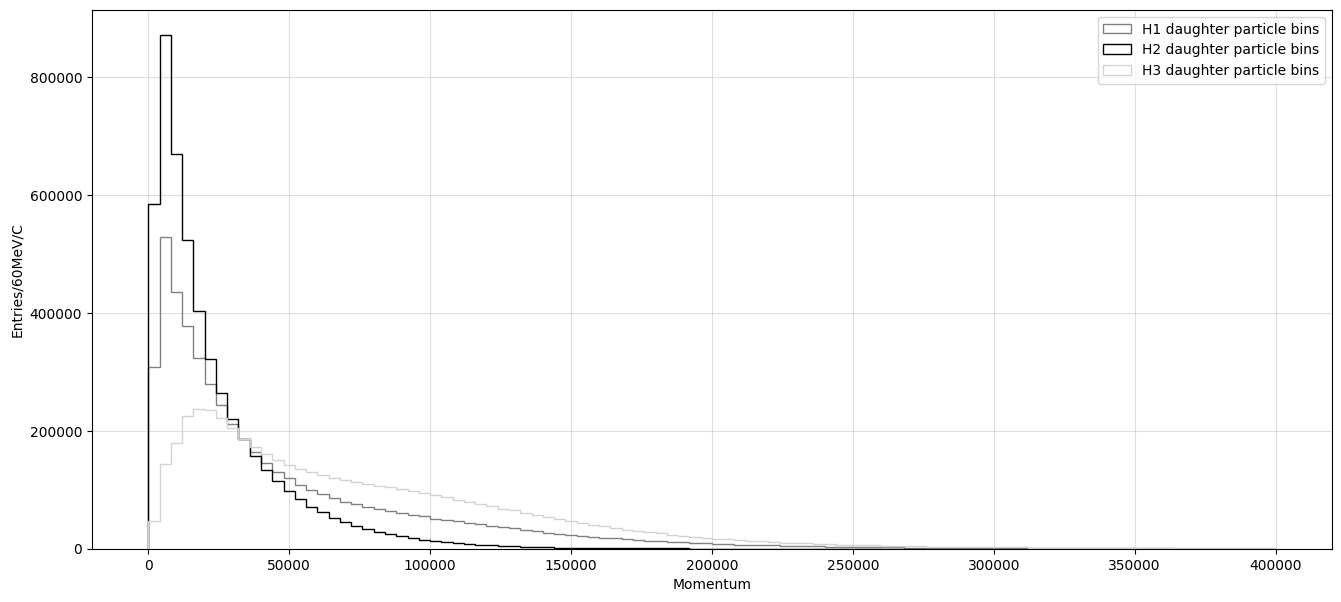

In [193]:
#Here make a plot of the Total momentum of each of the three daughters on one plot
x_min, x_max = 0,4e5
n_bins = 100
fig=plt.subplots(figsize=[16,7])
plt.hist(H1_Ptot,
         bins=n_bins,
         range=(x_min, x_max),
         histtype="step",
         label="H1 daughter particle bins",
         color="grey")
plt.hist(H2_Ptot,
         bins=n_bins,
         range=(x_min, x_max),
         histtype="step",
         label="H2 daughter particle bins",
         color="black")
plt.hist(H3_Ptot,
         bins=n_bins,
         range=(x_min, x_max),
         histtype="step",
         label="H3 daughter particle bins",
         color="lightgrey")
plt.ylabel("Entries/60MeV/C")
plt.xlabel("Momentum")
plt.legend()
plt.grid(alpha=0.4)
plt.show()



Now plot the total momentum for the mother (M_Ptot) this about how to calculate this from the information available

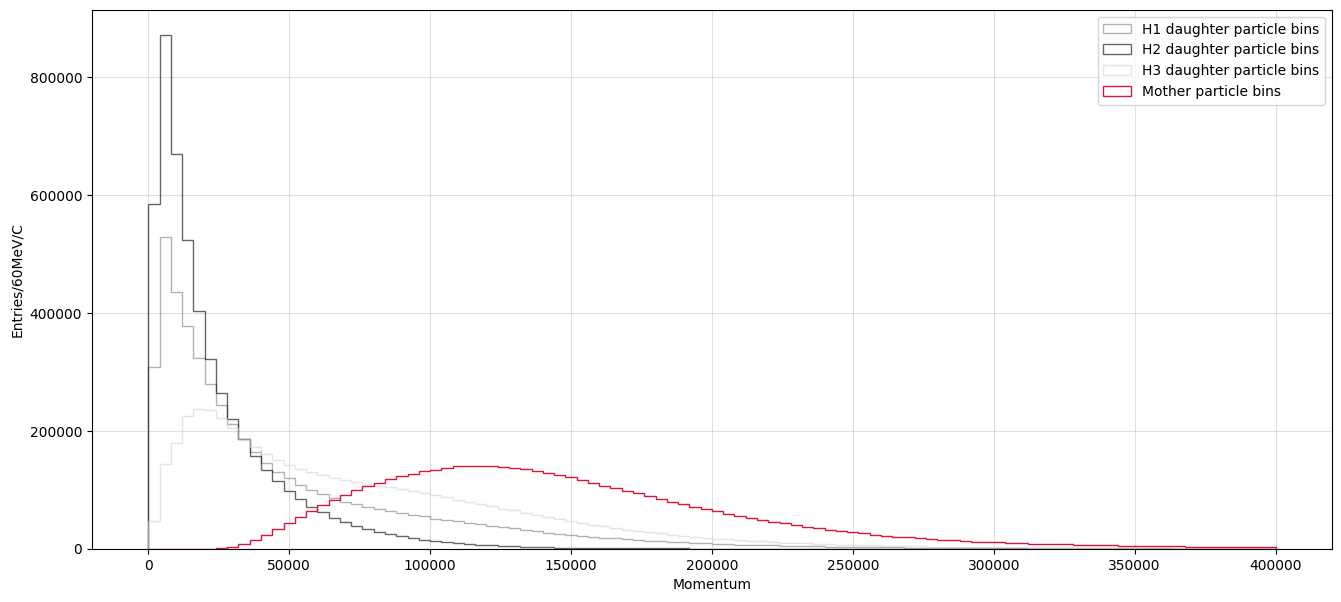

In [194]:
#-----comparison graph between daughter momenta and mother momentum-----#

M_Px = px_H1 + px_H2 + px_H3
M_Py = py_H1 + py_H2 + py_H3
M_Pz = pz_H1 + pz_H2 + pz_H3

M_Ptot = np.sqrt(M_Px**2 + M_Py**2 + M_Pz**2)
# print(M_Ptot)

fig=plt.subplots(figsize=[16,7])
plt.hist(H1_Ptot,
         bins=n_bins,
         range=(x_min, x_max),
         histtype="step",
         label="H1 daughter particle bins",
         color="grey",
         alpha=0.6)
plt.hist(H2_Ptot,
         bins=n_bins,
         range=(x_min, x_max),
         histtype="step",
         label="H2 daughter particle bins",
         color="black",
         alpha=0.6)
plt.hist(H3_Ptot,
         bins=n_bins,
         range=(x_min, x_max),
         histtype="step",
         label="H3 daughter particle bins",
         color="lightgrey",
         alpha=0.6)
plt.hist(M_Ptot,
         bins=n_bins,
         range=(x_min, x_max),
         histtype="step",
         label="Mother particle bins",
         color="crimson")
plt.ylabel("Entries/60MeV/C")
plt.xlabel("Momentum")
plt.legend()
plt.grid(alpha=0.4)
plt.show()

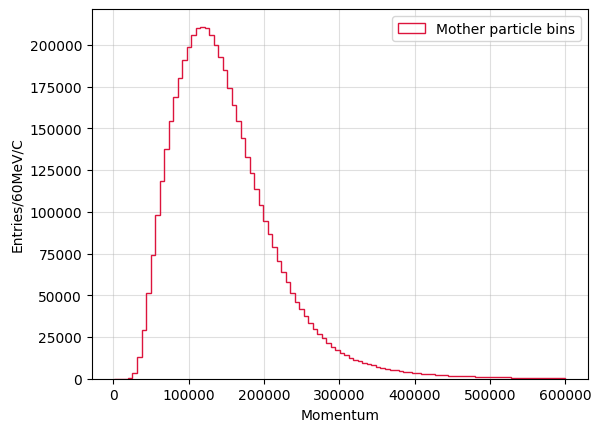

min & max of the mother particle: 19679.5945831008 & 149284.46333339717


In [195]:
x_min, x_max = 1500, (10**5)*5
plt.hist(M_Ptot,
         bins=n_bins,
         range=(x_min, 6e5),
         histtype="step",
         label="Mother particle bins",
         color="crimson")
plt.ylabel("Entries/60MeV/C")
plt.xlabel("Momentum")
plt.legend()

plt.grid(alpha=0.4)
plt.show()
print("min & max of the mother particle:", M_Ptot.min(), "&", M_Ptot.mean())

Let's take a look at the whole data file that is available to us by looking at one specific entry - for example the number 45th entry in your array...

In [196]:
# print the 45th entry from your array(s) together with the variable name, maybe in a nice list or table.
i=44
print("-----45th entries----- ")
print("Array:", "Momentum:")
print("#----Daughter particle H1----#")
print("px_H1,", px_H1[i])
print("py_H1,", py_H1[i])
print("pz_H1,", pz_H1[i])
print("H1_Ptot,", H1_Ptot[i])
print("#----Daughter particle H2----#")
print("px_H2,", px_H2[i])
print("py_H2,", py_H2[i])
print("pz_H2,", pz_H2[i])
print("H2_Ptot,", H2_Ptot[i])
print("#----Daughter particle H3----#")
print("px_H3,", px_H3[i])
print("py_H3,", py_H3[i])
print("pz_H3,", pz_H3[i])
print("H3_Ptot,", H3_Ptot[i])
print("#----Mother particle----#")
print("The mother particles total momentum is comprised of H1_tot, H2_tot, H3_tot")
print("M_Ptot,", M_Ptot[i])

-----45th entries----- 
Array: Momentum:
#----Daughter particle H1----#
px_H1, -1634.778090943406
py_H1, 838.6625674548812
pz_H1, 15416.880380015971
H1_Ptot, 15525.979999999998
#----Daughter particle H2----#
px_H2, -3456.1594387288615
py_H2, -328.7925226754248
pz_H2, 21752.773751811932
H2_Ptot, 22028.08
#----Daughter particle H3----#
px_H3, -2892.8286712088047
py_H3, -2105.6968313552316
pz_H3, 52930.48169790119
H3_Ptot, 53051.28
#----Mother particle----#
The mother particles total momentum is comprised of H1_tot, H2_tot, H3_tot
M_Ptot, 90467.24082461404


We have now completed the initial steps and begun to work through what we need to with the data. This is a perfect moment to take a coffee!

Having discovered all of the relevant information about our daughter particles, we need to combine the measurements about them into a single mother - which will be our B<sup>+</sup> or our B<sup>-</sup>

Having found our momentum and energy, we can use these quantities to find our experimental mass (not the theoretical mass as we have used for the reconstruction).

When we calculate this, we will get a distribution of masses. This is due to errors in the measurements made either by the detector, or in the experiment itself. We hope to have a reasonably narrow peak to work with, but, sometimes this is not possible.

Additionally there will be other particles in the detector - which means our daughters might have come from two or even three different processes. Events which don't come from the same process will give a higher or lower mass than we are looking for. This is typically called the *background* while events which come from our event of interest are called the *signal*

[175445.23507303 419291.17087521 194327.37077526 ...  54356.39745289
 157611.98567511 142225.23879559]


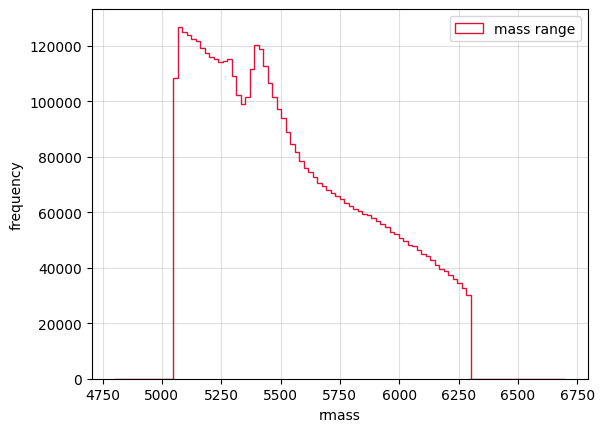

In [197]:
#First find the energy (you might have to do some physics thinking here)
#Mother = B

m_K = 493.677 #Mev/c^2

def energy(p,m_K): return np.sqrt(p**2 + m_K**2)
    
E_H1 = energy(H1_Ptot, m_K)
# print(len(E_H1))
E_H2 = energy(H2_Ptot, m_K)
# print(len(E_H2))
E_H3 = energy(H3_Ptot, m_K)
# print(len(E_H3))

E_B = E_H1 + E_H2 + E_H3
print(E_B)

# The using the total momentum find the reconstructed mass of the B
mass_B = np.sqrt(E_B**2 -M_Ptot**2)
# print(mass_B)

# for i in range(0, len(B_C)):
#     if B_C[i] == 1:

#         print("test")
#     if B_C[i] == -1:
#         print("test")
# B_C = H1_C + H2_C + H3_C

# B_Cneg = [] #B-
# B_Cpos = [] #B+

#Now plot a histogram of the range of masses of the B meson.

fig = plt.hist(mass_B,
               bins = n_bins, 
               range=(4800, 6700), 
               
               histtype="step", 
               label="mass range",
               color="crimson")
plt.ylabel("frequency")
plt.xlabel("rmass")
plt.legend()
plt.grid(alpha=0.4)
plt.show()
#Does this match what we would expect from theory?

#What are the features of your plot that you see?

We know that some of our particles are the B+ and some are the B- particle. There will also be some particles in our system that are not coming from a genuine B+/- or are a B+/- but are not constructed from Kaons.

We have some tools available to help:-

  *  During detection, software attributes the probability of a particle being a Kaon or a Pion (in the H1_ProbK or H1_ProbPi variable)
  * The detector also knows if the particle was a Muon - since it has detectors specifically for these. So it can attribute a 0 or a 1 to this probability
  * The reconstructed vertex has a some kind of quality associated with it (we call this the Vertex χ2 (this is the variable B_VertexChi2). This is the statistical measure that determines how well we found a single point to be the source of all three particles.



In order to get a better result, we should select our data to have the properties we desire and make some rules (often called a selection) to cut away data we don't want to include for various reasons. e.g. we know we don't have any muons in our decay - so any time H1/H2/H3 are a muon they should be excluded. The other variables are not so clear - so we can plot them to make a decision.

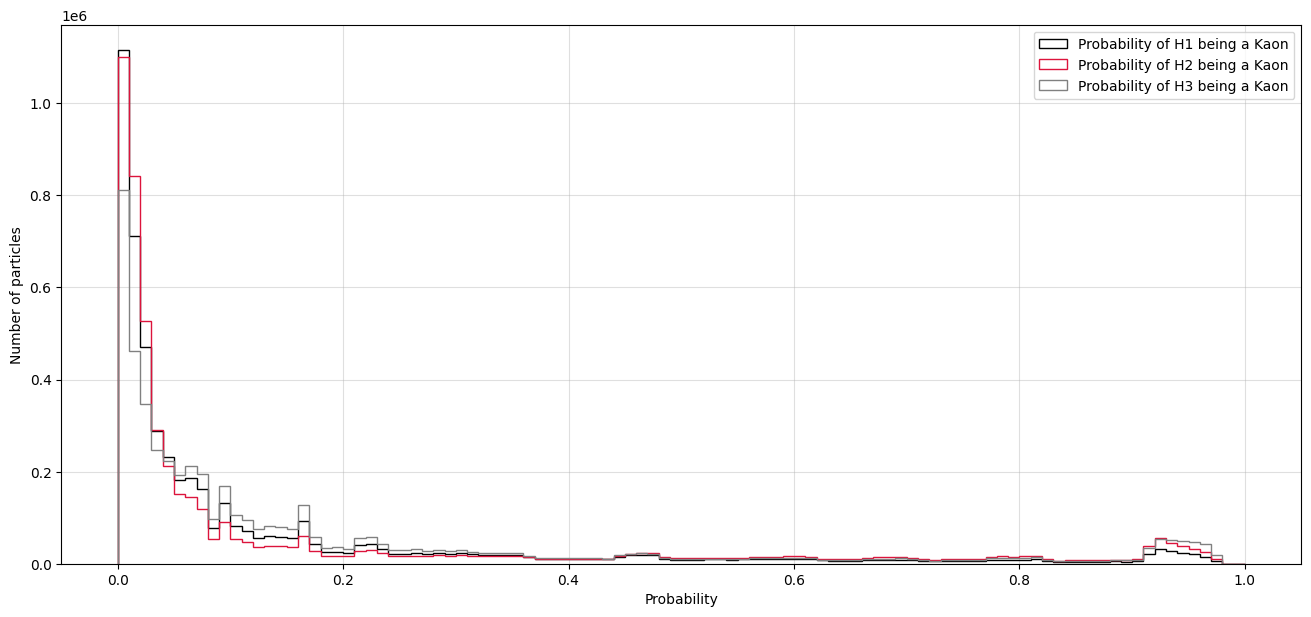

In [198]:
#Make plots of H1/H2/H3 _ProbK on one plot
H1_probK= tree["H1_ProbK"].array(library="np")
H2_probK= tree["H2_ProbK"].array(library="np")
H3_probK= tree["H3_ProbK"].array(library="np")

fig = plt.subplots(figsize=[16,7])
fig = plt.hist(H1_probK,
               bins = 100, 
               range=(0, 1),
               histtype="step", 
               label="Probability of H1 being a Kaon",
               color="black")

fig = plt.hist(H2_probK,
               bins = 100, 
               range=(0, 1),
               histtype="step", 
               label="Probability of H2 being a Kaon",
               color="crimson")

fig = plt.hist(H3_probK,
               bins = 100, 
               range=(0, 1),
               histtype="step", 
               label="Probability of H3 being a Kaon",
               color="grey")
plt.ylabel("Number of particles")
plt.xlabel("Probability")
plt.grid(alpha=0.4)
plt.legend()
plt.show()


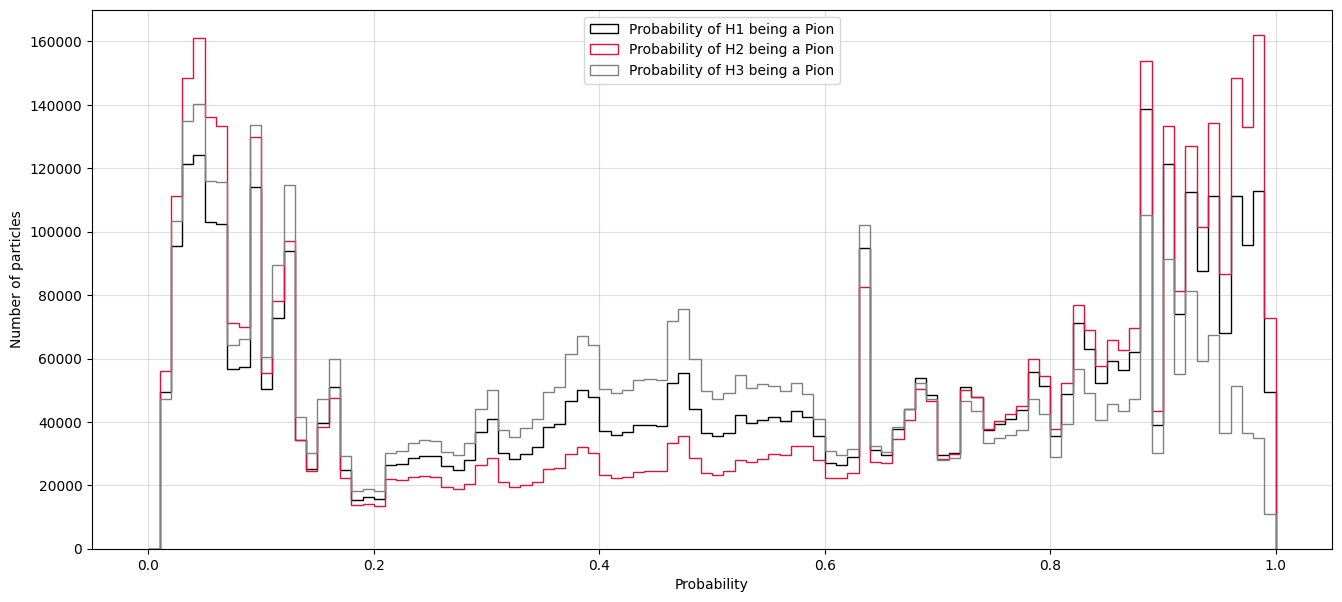

In [199]:
# Do the same for the Probability of being a Pion. Do these distributions match expectations?
H1_probPi= tree["H1_ProbPi"].array(library="np")
H2_probPi= tree["H2_ProbPi"].array(library="np")
H3_probPi= tree["H3_ProbPi"].array(library="np")

fig = plt.subplots(figsize=[16,7])
fig = plt.hist(H1_probPi,
               bins = 100, 
               range=(0, 1),
               histtype="step", 
               label="Probability of H1 being a Pion",
               color="black")

fig = plt.hist(H2_probPi,
               bins = 100, 
               range=(0, 1),
               histtype="step", 
               label="Probability of H2 being a Pion",
               color="crimson")

fig = plt.hist(H3_probPi,
               bins = 100, 
               range=(0, 1),
               histtype="step", 
               label="Probability of H3 being a Pion",
               color="grey")
plt.ylabel("Number of particles")
plt.xlabel("Probability")
plt.grid(alpha=0.4)
plt.legend()
plt.show()

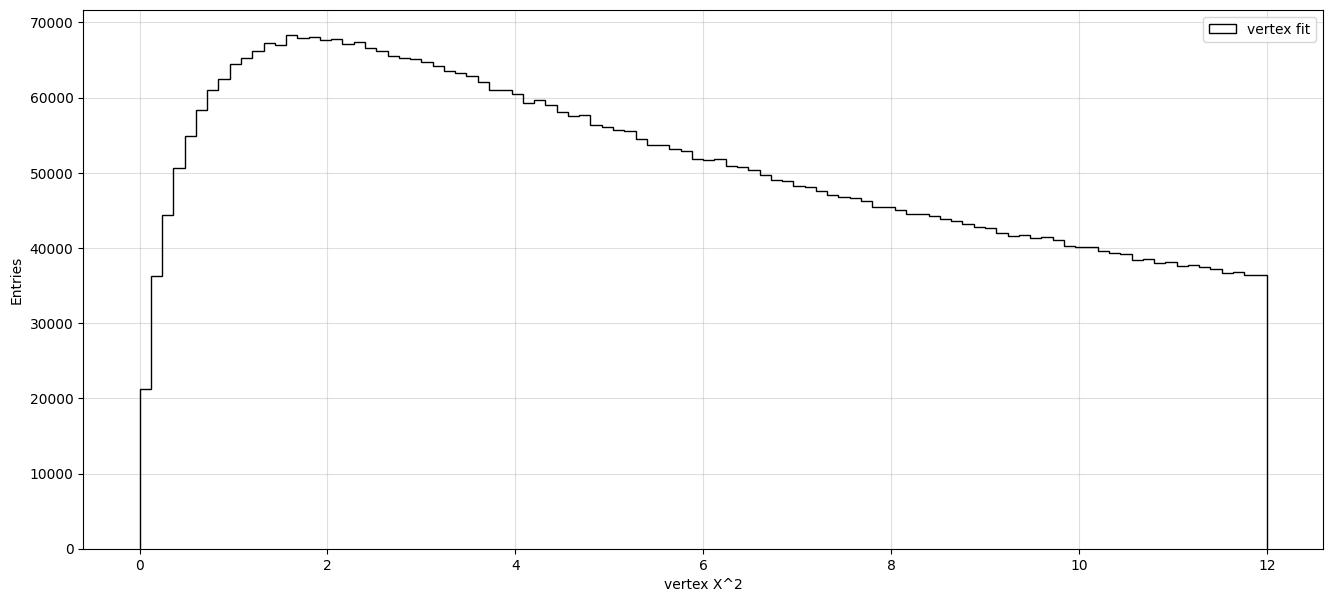

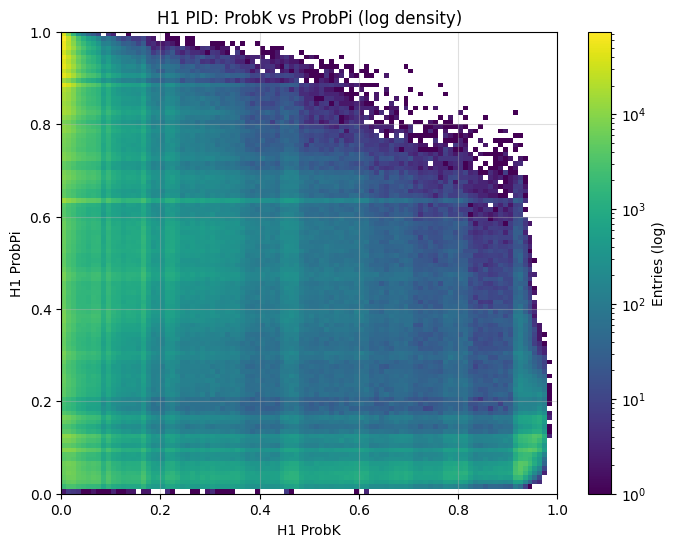

In [200]:
#For all our particles, make a plot of the B_VertexChi2
B_Chi2= tree["B_VertexChi2"].array(library="np")


fig = plt.figure(figsize=[16,7])
fig = plt.hist(B_Chi2,
               bins = 100,
               histtype="step", 
               label="vertex fit",
               color="black")
plt.ylabel("Entries")
plt.xlabel("vertex X^2")
plt.grid(alpha=0.4)
plt.legend()
plt.show()

#Feeling ambitious? Maybe make a 2d plot of Kaon and Pion Prob in a 2 dimensional analysis?
K_totprob = H1_probK + H2_probK + H3_probK
Pi_totprob = H1_probPi + H2_probPi + H3_probPi

plt.figure(figsize=(8,6))
plt.hist2d(H1_probK, H1_probPi, bins=100, range=[[0,1],[0,1]], norm = LogNorm())
plt.title("H1 PID: ProbK vs ProbPi (log density)")
plt.xlabel("H1 ProbK")
plt.ylabel("H1 ProbPi")
plt.colorbar(label="Entries (log)")
plt.grid(alpha=0.4)
plt.show()



Using these plots, we can now make a preselection string. This is a text string that looks like

In [230]:
#This example is for each daughter particle to have a Probability of being a Pion being more than 90% and H1 to not be a muon
#This is not a good choice of selection - you should make your own :)

H1_C = tree["H1_Charge"].array(library="np")
H2_C = tree["H2_Charge"].array(library="np")
H3_C = tree["H3_Charge"].array(library="np")

#Consider possible charges of the meson
Charge_B = H1_C + H2_C + H3_C

BC_p = (Charge_B == 1)
BC_m = (Charge_B == -1)


H1_Muon = tree["H1_isMuon"].array(library="np")
H2_Muon = tree["H2_isMuon"].array(library="np")
H3_Muon = tree["H3_isMuon"].array(library="np")

isMuon = ((H1_Muon == 0 ) &  (H2_Muon == 0) & (H3_Muon == 0))

#Consider impact Parameters (Saw this in a google search for how selections are typically made)
H1_IP = tree["H1_IPChi2"].array(library="np")
H2_IP = tree["H2_IPChi2"].array(library="np")
H3_IP = tree["H3_IPChi2"].array(library="np")

IP_cut = (H1_IP > 4) & (H2_IP > 4) & (H3_IP > 4)

#cut vertex quality (Saw this in a google search for how selections are typically made, Vertex graph shows high around up to 4.)
Vertex_cut = (B_Chi2 < 4)

#Cut probabilities sensibly
B_probPi = (H1_probPi < 0.6) & (H2_probPi < 0.6) & (H3_probPi < 0.6)
B_probK =   (H1_probK  > 0.2) & (H2_probK  > 0.2) & (H3_probK  > 0.2)

#here i already divided them per mother particle charge 
#B+
selectionB_p = (B_probPi & B_probK & isMuon & BC_p & Vertex_cut & IP_cut)
#B- 
selectionB_m = (B_probPi & B_probK & isMuon & BC_m & Vertex_cut & IP_cut)

#Separation of Mother particles by +- charge 
B_tot = BC_p | BC_m #All possible B mother particles with either positive or negative charge
selection_tot = selectionB_p | selectionB_m #all possible selections which were divided by charge initially.


#Comparison charge wise
print("B+ before:", np.sum(BC_p))
print("B+ after :", np.sum(selectionB_p))

print("B- before:", np.sum(BC_m))
print("B- after :", np.sum(selectionB_m))



B+ before: 2610178
B+ after : 8890
B- before: 2525645
B- after : 8148


In [231]:
print("Total:", len(mass_B))
print("Charge B+ :", np.sum(BC_p))
print("Charge B- :", np.sum(BC_m))
print("Muon:", np.sum(isMuon))
print("Impact Parameter cut:", np.sum(IP_cut))
print("Vertex cut:", np.sum(Vertex_cut))
print("Pion Probability  :", np.sum(B_probPi))
print("Kaon Probability:", np.sum(B_probK))


Total: 5135823
Charge B+ : 2610178
Charge B- : 2525645
Muon: 3806297
Impact Parameter cut: 2512563
Vertex cut: 2044766
Pion Probability  : 867857
Kaon Probability: 71217


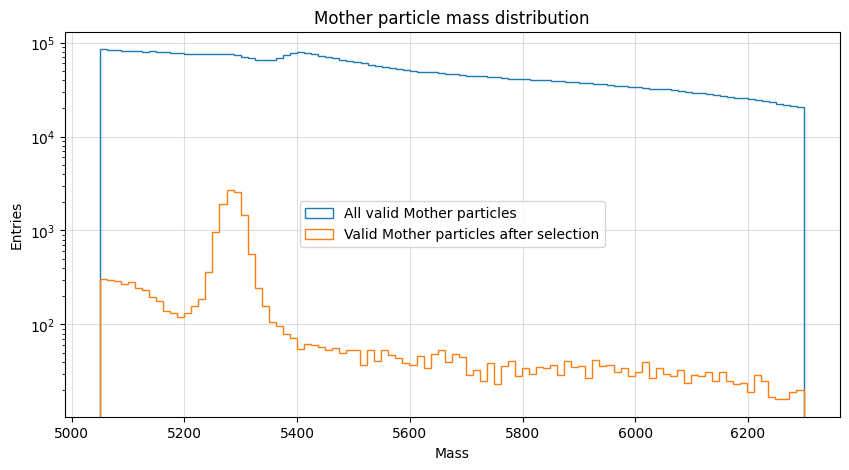

In [232]:
#Now as a good check, we should see the effect of applying our cuts.
#On one histogram, plot the B meson mass, from both the tree (pre-cuts) and the CutTree (post-cuts)
#What do you notice about your histogram now?

#plotting mass distribution (one valid mother particle that can be filtered)
plt.figure(figsize=(10,5))
plt.hist(mass_B[B_tot], bins=100, histtype='step', label='All valid Mother particles')
plt.hist(mass_B[selection_tot], bins=100, histtype='step', label='Valid Mother particles after selection')
plt.xlabel("Mass")
plt.ylabel("Entries")
plt.title("Mother particle mass distribution")
plt.yscale("log")
plt.grid(alpha=0.4)
plt.legend()
plt.show()


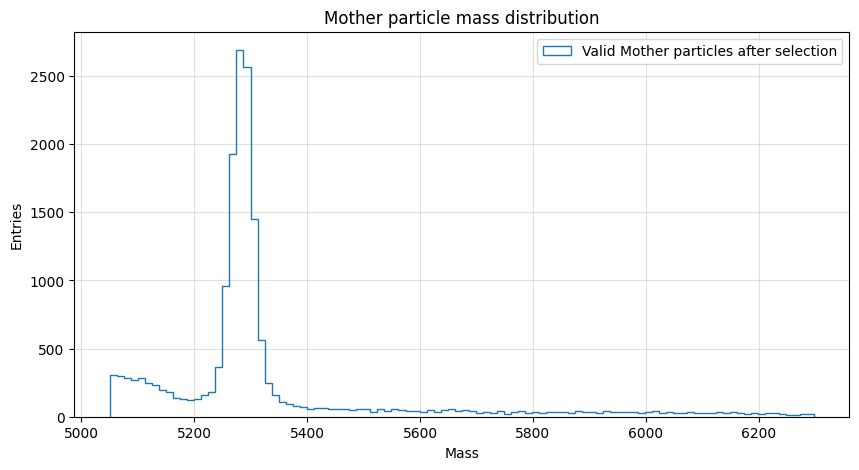

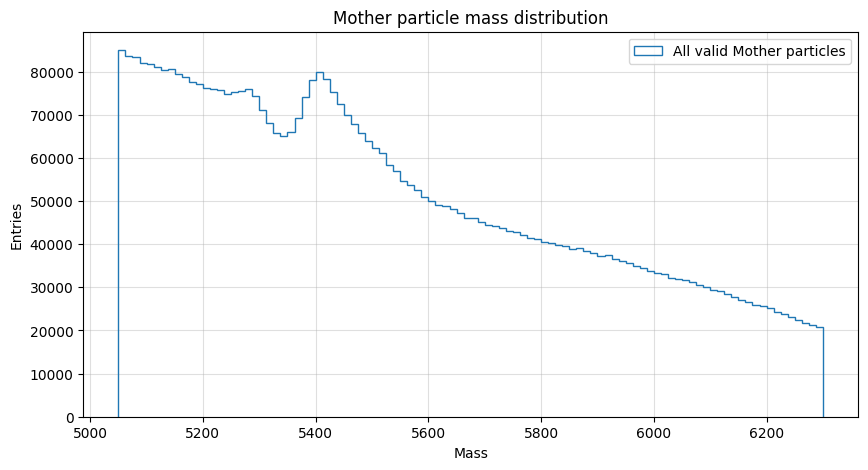

In [234]:
#You can also plot your selected data alone - this shape probably looks quite alot different to your first distribution!
plt.figure(figsize=(10,5))
plt.hist(mass_B[selection_tot], bins=100, histtype='step', label='Valid Mother particles after selection')
plt.xlabel("Mass")
plt.ylabel("Entries")
plt.title("Mother particle mass distribution")
plt.grid(alpha=0.4)
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.hist(mass_B, bins=100, histtype='step', label='All valid Mother particles')
plt.xlabel("Mass")
plt.ylabel("Entries")
plt.title("Mother particle mass distribution")
plt.grid(alpha=0.4)
plt.legend()
plt.show()

#How do we count the number of events?

We now have a histogram of events that we have reconstructed as a B meson. But some of these events are caused by a co-incidence of events which would still occur if there were no B mesons actually produced. We call this the background. Background and signal are indistinguishable now as the detector cannot tell the difference and our cuts were unable to remove the events for physics reasons. We can do some statistical analysis, if we know the approximate shapes of our signal and our background. Just like a least-squares fitting we can run a fit routine to minimise the error between the fitted curve and our data. As an example, if we know our data has an exponential background and a gaussian signal:

![Gaussian+Exp Background](https://twiki.cern.ch/twiki/pub/RooStats/RooStatsTutorialsJune2013/GausExpModelFit.png)

Here the red line represents our signal, the blue dotted line is our background and the solid blue line is our combined curve. The graph also shows the number of signal events and the number of background events. The signal now is a tiny fraction of the total data shown in the plot.

In order to do this, we need to build a fit model, around which the software can try to fit our data.

We use RooFit for this, which includes:
* Gaussian
* Exponential
* Chebychev
* Crystal Ball
* Breit-Wigner

As well as several other choices.

Typically exponential and Chebychev functions are used for background and Gaussian, Crystal Ball and Breit-Wigner are used for signal. We can also combine them (e.g. 1 crystal ball, 1 gaussian, 1 exponential) in various ways.

In [205]:
!pip install lmfit
# check out its documentation for what shapes it can handle for you! https://pypi.org/project/lmfit/


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


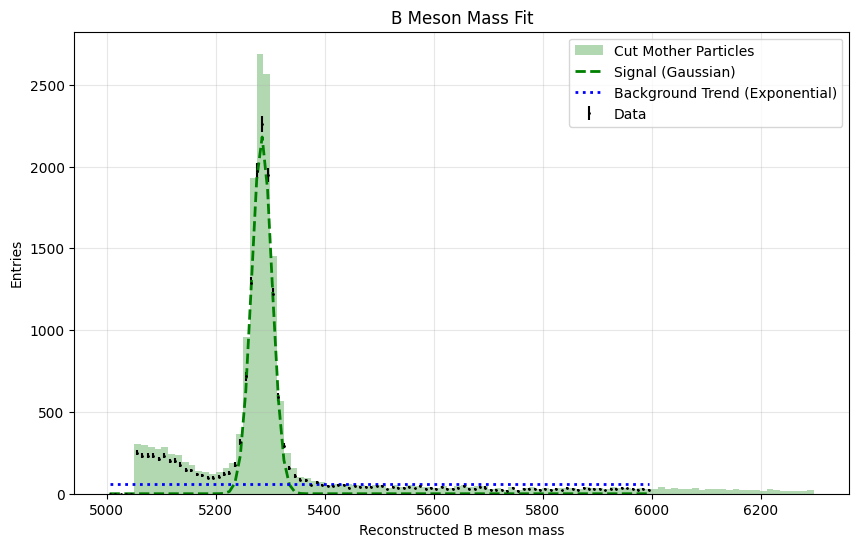

[[Model]]
    (Model(gaussian, prefix='sig_') + Model(exponential, prefix='bkg_'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 1041
    # data points      = 100
    # variables        = 5
    chi-square         = 343856.608
    reduced chi-square = 3619.54324
    Akaike info crit   = 824.280983
    Bayesian info crit = 837.306834
    R-squared          = 0.97714446
##  Warning: uncertainties could not be estimated:
[[Variables]]
    bkg_amplitude:  62.1620833 (init = 1.009521e-19)
    bkg_decay:     -9.2120e+15 (init = -119.6262)
    sig_amplitude:  102017.917 (init = 10000)
    sig_center:     5284.40194 (init = 5300)
    sig_sigma:      18.6507662 (init = 15)
    sig_fwhm:       43.9191973 == '2.3548200*sig_sigma'
    sig_height:     2182.17642 == '0.3989423*sig_amplitude/max(1e-15, sig_sigma)'


In [271]:
#use my example of creating a PDF (far far) above to do a fit to your data. Start with one component, think about making a number 2 component plot - so we have a part for the background and a part for the signal.
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import lmfit
from lmfit.models import GaussianModel, ExponentialModel 

#initialise data
data = mass_B[selection_tot] 
x_min, x_max = 5000, 6000 #notice peak mass of cut data around 5300~
n_bins = 100

# Create the histogram
counts, bin_edges = np.histogram(data, bins=n_bins, range=(x_min, x_max))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

#Define models
sig = GaussianModel(prefix="sig_")
bkg = ExponentialModel(prefix="bkg_")

# Combine them into one model
model = sig + bkg

#Initial guess following the background
params = bkg.guess(counts, x=bin_centers)

#manually set the signal parameters 
params.update(sig.make_params(
    center=5300,      # The known B meson mass
    sigma=15,         # A reasonable starting width
    amplitude=10000
))

# 4. Perform the Fit
result = model.fit(counts, params, x=bin_centers)

# 5. Plot the Results
plt.figure(figsize=(10, 6))

# Ploting data with Error Bars
plt.errorbar(bin_centers, counts, yerr=np.sqrt(counts), fmt='k.', label='Data', markersize=2)

#Total Fit (Signal + Background)
# plt.plot(bin_centers, result.best_fit, 'r-', label='Total Fit', linewidth=2)

#individual components
comps = result.eval_components(x=bin_centers)
plt.hist(data,bins=100, histtype='bar', label='Cut Mother Particles', alpha = 0.3, color = "green")
plt.plot(bin_centers, comps['sig_'], 'g--', label='Signal (Gaussian)', linewidth=2)
plt.plot(bin_centers, comps['bkg_'], 'b:', label='Background Trend (Exponential)', linewidth=2)

plt.xlabel("Reconstructed B meson mass")
plt.ylabel("Entries")
plt.title("B Meson Mass Fit")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Print the fit statistics
print(result.fit_report())
# if your cut is very strict above, you may actually get better results by being less strict, give yourself more data and more events to run through the fitting procedure.

Using this structure, you can in theory build whatever models you like!

Some recommendations (but not necessary to do all):-



*   Gauss+Exponential (as above)
*   Crystal Ball + Exponential
*   Gauss+Crystal Ball+Exponential (now you need to weigh the two signal peaks and then the total signal against total background)
*   Gauss+Chebychev
*   Two Crystal Balls + Exponential

So how good was the fit, and how many events do you have?

You can use the signal shape, the bin widths and the quad from scipy.integrate function to "count" how many events lie under your signal peak,  not including the background events - this is what we actually want.

It will also return to you an error - check in the scipy documentation about what that actually means....

In [ ]:
#find the area under your curve(s)! maybe make a pretty little table...

from scipy.integrate import quad 

#assigns sig onto a numpy array, basically seperates components only to store sig.
def signal_func(x): return result.eval_components(x=np.array([x]))["sig_"][0]


#integral over the interesting chunk of the signal
area,error = quad(signal_func, 5000, 6000)

#calc. to get yield
bin_width = bin_edges[1] - bin_edges[0]
yield_events = area / bin_width


print("Area under signal including calc. error:", area, "+-", error )
print("Number of Signal Events (Yield):", yield_events)


Area under signal including calc. error: 102189.43156508877 +- 0.000845797495744538
Number of Signal Events (Yield): 10218.943156508878


#Counting

So we have now loaded our data; we have reconstructed information about the mother B meson and we have cut away any data which looks like it might not be what we are looking for. We have then plotted histograms of the mass of the B meson and used this to fit a model, a function to describe the events there. We now have to identify which of our events belong to the B<sup>+</sup> and how many of them belong to B<sup>-</sup>.

To do this, should split out data into two groups (and throw away data which doesn't comply with either decay)

We will be looking for the events which are


B<sup>+</sup>->K<sup>+</sup> + K<sup>+</sup>  + K<sup>-</sup>

or

B<sup>-</sup>->K<sup>-</sup> + K<sup>-</sup>  + K<sup>+</sup>

We can look for the number of positive and negative charges in H1, H2 and H3 (using the variable ```H1_Charge``` etc.). If we have 0 or 3 positive charges, we should throw the event away and if we have 1 it should be assigned be a B<sup>-</sup>, with 2 it should be a B<sup>+</sup>

Once we have defined if it's a B<sup>+</sup> or a B <sup>-</sup>, we should go ahead and ensure the pre-selection is applied and then plot our B mass, and fit the model to find the yield.

We can then calculate the assymetry from this equation:

$A=\frac{(N^{B-}-N^{B+})}{(N^{B-}+N^{B+})}$

Where N<sup>B+/- </sup> is the number of events found from the fitted yield of the signal from each data set.

The uncertainty on this result is given by:

$\sigma_A=\sqrt\frac{1-A^2}{N^{B-}+N^{B+}}$

Calculate these two values for your data and print them below:

In [273]:
#Here do your calculation of the final result


B_P = mass_B[selectionB_p]
B_M = mass_B[selectionB_m]

def count(masses, center=5300, width=30):
    return ((masses > center - width) & (masses < center + width)).sum()

N_Bp  = count(B_P)
N_Bm = count(B_M)

A =(N_Bm - N_Bp) / (N_Bm + N_Bp)
sig_A = np.sqrt((1-A**2)/(N_Bm + N_Bp))


print("Np", N_Bp)
print("Nm", N_Bm)
print("Assymetry:", A)
print("Uncertainty", sig_A)



Np 4293
Nm 3999
Assymetry: -0.03545586107091172
Uncertainty 0.010974814839955712


#Congratulations!

You just made your first LHCb physics analysis. Does this seem like a reasonable result? Did we explain why we have an excess of mass in the Universe?

## **Bonus content only below here:**

To make a further anaysis, we can look into the intermediate processes.

We have so far considered only that the B meson ultimately decays into three kaons. It may be that on the way, the B meson first decays into a Kaon and another particle, and then from that particle to two Kaons.

We would expect this to be one of three possible modes (for B<sup>+</sup>):

$R^{++} \rightarrow K_1^+ +K_2^+$

(we don't expect this to happen because of the like charges in the Kaons)

$R^0 \rightarrow K_1^+ +K_3^-$

$R^0 \rightarrow K_2^+ +K_3^-$

(Expect symmetric arrangements for B<sup>-</sup>)

To analyse the intermediate states we can measure the invarient masses of the intermediate states and then plot them on what is called a Dalitz plot (this is a 2D plot with two different two body decays (from the three body decay) on each axis)

![Dalitz Plot](https://slideplayer.com/slide/15960097/88/images/15/Dalitz+plot%3A+%CE%9B+c+%2B+%E2%86%92%F0%9D%91%9D+%F0%9D%90%BE+%E2%88%92+%F0%9D%9C%8B+%2B.jpg)


In [209]:
#Define a function to find the invarient mass of two given Kaons

In [210]:
#Then, ensuring you're still taking the data after the selection, make a Dalitz plot. This is a 2-D scatter plot (use e.g. TH2F to make the plot where we used TH1F before)
#Choose an appropriate binning in your scatter

We can further improve our plot, since two sets of particles on each axis are exactly the same (one positive Kaon, one negative Kaon). So we can plot the maximum of the two values on one axis and the minimum on the other. We can use a quick numpy check and then plot those values.

In [211]:
#Make the revised Dalitz plot here for B+ mesons

In [212]:
#Make the revised Dalitz plot here for B- mesons

In [213]:
#Where we have a higher density of points (or a bigger value in the bin) this is indication of an intermediate resonance
#Check out the possible resonances you have found in the PDG (http://pdg.lbl.gov/2020/tables/contents_tables.html)